In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch

base = "/content/drive/MyDrive/Weather"  # change if your path differs

train = torch.load(f"{base}/train_tn_tx.pt", map_location="cpu")
val   = torch.load(f"{base}/val_tn_tx.pt", map_location="cpu")
test  = torch.load(f"{base}/test_tn_tx.pt", map_location="cpu")

print("Loaded files:")
print(" train keys:", list(train.keys()))
print(" val keys:  ", list(val.keys()))
print(" test keys: ", list(test.keys()))

Mounted at /content/drive
Loaded files:
 train keys: ['X_num', 'station_id', 'dept_id', 'y', 'meta', 'numeric_feature_cols', 'norm_stats', 'station_to_id', 'dept_to_id', 'input_len', 'output_len', 'target_cols']
 val keys:   ['X_num', 'station_id', 'dept_id', 'y', 'meta', 'numeric_feature_cols', 'norm_stats', 'station_to_id', 'dept_to_id', 'input_len', 'output_len', 'target_cols']
 test keys:  ['X_num', 'station_id', 'dept_id', 'y', 'meta', 'numeric_feature_cols', 'norm_stats', 'station_to_id', 'dept_to_id', 'input_len', 'output_len', 'target_cols']


In [2]:
def inspect_split(name, d):
    print(f"\n=== {name.upper()} ===")
    for k in ["X_num", "y", "station_id", "dept_id"]:
        x = d[k]
        print(f"{k:12s} shape={tuple(x.shape)} dtype={x.dtype}")

    print("input_len   :", d["input_len"])
    print("output_len  :", d["output_len"])
    print("target_cols :", d["target_cols"])
    print("num feats   :", len(d["numeric_feature_cols"]))
    print("station ids :", len(d["station_to_id"]))
    print("dept ids    :", len(d["dept_to_id"]))

    X = d["X_num"]
    y = d["y"]
    sid = d["station_id"]
    did = d["dept_id"]

    print("X_num min/max/mean/std:",
          X.min().item(), X.max().item(), X.mean().item(), X.std().item())
    print("y min/max/mean/std:",
          y.min().item(), y.max().item(), y.mean().item(), y.std().item())

    print("station_id min/max/unique:",
          sid.min().item(), sid.max().item(), sid.unique().numel())
    print("dept_id min/max/unique:",
          did.min().item(), did.max().item(), did.unique().numel())

inspect_split("train", train)
inspect_split("val", val)
inspect_split("test", test)


=== TRAIN ===
X_num        shape=(32778, 36, 37) dtype=torch.float32
y            shape=(32778, 12, 2) dtype=torch.float32
station_id   shape=(32778,) dtype=torch.int64
dept_id      shape=(32778,) dtype=torch.int64
input_len   : 36
output_len  : 12
target_cols : ['TN', 'TX']
num feats   : 37
station ids : 3530
dept ids    : 95
X_num min/max/mean/std: -17.700000762939453 204.05259704589844 0.662238359451294 3.3869097232818604
y min/max/mean/std: -17.700000762939453 37.29999923706055 11.798717498779297 8.117149353027344
station_id min/max/unique: 0 3529 2691
dept_id min/max/unique: 0 94 95

=== VAL ===
X_num        shape=(2901, 36, 37) dtype=torch.float32
y            shape=(2901, 12, 2) dtype=torch.float32
station_id   shape=(2901,) dtype=torch.int64
dept_id      shape=(2901,) dtype=torch.int64
input_len   : 36
output_len  : 12
target_cols : ['TN', 'TX']
num feats   : 37
station ids : 3530
dept ids    : 95
X_num min/max/mean/std: -15.600000381469727 117.80699157714844 0.773465573787689

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

class WeatherSeqDataset(Dataset):
    def __init__(self, pack):
        self.X_num = pack["X_num"].float()
        self.station_id = pack["station_id"].long()
        self.dept_id = pack["dept_id"].long()
        self.y = pack["y"].float()
        self.meta = pack["meta"]

    def __len__(self):
        return self.X_num.shape[0]

    def __getitem__(self, idx):
        return {
            "X_num": self.X_num[idx],           # [36, n_features]
            "station_id": self.station_id[idx], # scalar
            "dept_id": self.dept_id[idx],       # scalar
            "y": self.y[idx],                   # [12, 2]
            "meta": self.meta[idx],
        }

# Build datasets from your currently loaded dicts
train_ds = WeatherSeqDataset(train)
val_ds   = WeatherSeqDataset(val)
test_ds  = WeatherSeqDataset(test)

print("Dataset sizes:")
print(" train:", len(train_ds))
print(" val:  ", len(val_ds))
print(" test: ", len(test_ds))

# DataLoaders
BATCH_SIZE = 128

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Sanity check one batch
batch = next(iter(train_loader))

print("\nOne train batch:")
print(" X_num     :", batch["X_num"].shape, batch["X_num"].dtype)
print(" station_id:", batch["station_id"].shape, batch["station_id"].dtype)
print(" dept_id   :", batch["dept_id"].shape, batch["dept_id"].dtype)
print(" y         :", batch["y"].shape, batch["y"].dtype)

assert batch["X_num"].shape[1] == 36
assert batch["y"].shape[1:] == (12, 2)
assert batch["station_id"].ndim == 1
assert batch["dept_id"].ndim == 1

print("\nBatch sanity check passed.")

Dataset sizes:
 train: 32778
 val:   2901
 test:  3228

One train batch:
 X_num     : torch.Size([128, 36, 37]) torch.float32
 station_id: torch.Size([128]) torch.int64
 dept_id   : torch.Size([128]) torch.int64
 y         : torch.Size([128, 12, 2]) torch.float32

Batch sanity check passed.


In [4]:
import torch
import torch.nn as nn

class EncoderDecoderLSTM(nn.Module):
    def __init__(
        self,
        n_num_features,
        n_stations,
        n_departments,
        station_emb_dim=64,
        dept_emb_dim=16,
        hidden_size=128,
        num_layers=2,
        dropout=0.2,
        output_len=12,
        output_dim=2,   # TN and TX
    ):
        super().__init__()
        self.output_len = output_len
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_dim = output_dim

        # Embeddings
        self.station_emb = nn.Embedding(n_stations, station_emb_dim)
        self.dept_emb = nn.Embedding(n_departments, dept_emb_dim)

        # Encoder input dim = numeric features + embeddings
        enc_input_dim = n_num_features + station_emb_dim + dept_emb_dim

        # Encoder
        self.encoder = nn.LSTM(
            input_size=enc_input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Decoder: receives zero inputs, conditioned on encoder state
        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Map decoder outputs to 2 values per month: TN and TX
        self.head = nn.Linear(hidden_size, output_dim)

    def forward(self, X_num, station_id, dept_id):
        """
        X_num:      [B, 36, n_num_features]
        station_id: [B]
        dept_id:    [B]
        returns:    [B, 12, 2]
        """
        B, T, _ = X_num.shape

        # Embeddings
        s_emb = self.station_emb(station_id)  # [B, 64]
        d_emb = self.dept_emb(dept_id)         # [B, 16]

        # Repeat embeddings across time
        s_rep = s_emb.unsqueeze(1).expand(B, T, s_emb.shape[-1])  # [B, 36, 64]
        d_rep = d_emb.unsqueeze(1).expand(B, T, d_emb.shape[-1])  # [B, 36, 16]

        # Encoder input
        enc_in = torch.cat([X_num, s_rep, d_rep], dim=-1)          # [B, 36, n_num_features+80]

        # Encode history
        _, (h, c) = self.encoder(enc_in)

        # Decoder input: zeros
        dec_in = torch.zeros(B, self.output_len, self.hidden_size, device=X_num.device)

        # Decode future steps
        dec_out, _ = self.decoder(dec_in, (h, c))                  # [B, 12, hidden]

        # Predict TN and TX per step
        y_hat = self.head(dec_out)                                 # [B, 12, 2]
        return y_hat


# ---- Instantiate model ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_num_features = train["X_num"].shape[-1]
n_stations = len(train["station_to_id"])
n_departments = len(train["dept_to_id"])

model = EncoderDecoderLSTM(
    n_num_features=n_num_features,
    n_stations=n_stations,
    n_departments=n_departments,
    station_emb_dim=64,
    dept_emb_dim=16,
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    output_len=12,
    output_dim=2,
).to(device)

print(model)

# ---- Sanity check with one batch ----
batch = next(iter(train_loader))

X_num = batch["X_num"].to(device)
station_id = batch["station_id"].to(device)
dept_id = batch["dept_id"].to(device)

with torch.no_grad():
    y_hat = model(X_num, station_id, dept_id)

print("\nInput shapes:")
print(" X_num     :", X_num.shape)
print(" station_id:", station_id.shape)
print(" dept_id   :", dept_id.shape)

print("\nOutput shape:")
print(" y_hat     :", y_hat.shape)

assert y_hat.shape == (X_num.shape[0], 12, 2), f"Bad output shape: {y_hat.shape}"
print("\nForward pass sanity check passed.")

EncoderDecoderLSTM(
  (station_emb): Embedding(3530, 64)
  (dept_emb): Embedding(95, 16)
  (encoder): LSTM(117, 128, num_layers=2, batch_first=True, dropout=0.2)
  (decoder): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Linear(in_features=128, out_features=2, bias=True)
)

Input shapes:
 X_num     : torch.Size([128, 36, 37])
 station_id: torch.Size([128])
 dept_id   : torch.Size([128])

Output shape:
 y_hat     : torch.Size([128, 12, 2])

Forward pass sanity check passed.


Epoch 01 | lr=9.80e-04 | train MSE=39.6556 RMSE=6.2973 MAE=4.4406 | val MSE=6.9147 RMSE=2.6296 MAE=2.0598
  -> saved new best model to best_lstm_tn_tx.pt
Epoch 02 | lr=9.60e-04 | train MSE=4.0723 RMSE=2.0180 MAE=1.5828 | val MSE=4.0714 RMSE=2.0178 MAE=1.5931
  -> saved new best model to best_lstm_tn_tx.pt
Epoch 03 | lr=9.41e-04 | train MSE=2.9454 RMSE=1.7162 MAE=1.3420 | val MSE=3.8642 RMSE=1.9657 MAE=1.5341
  -> saved new best model to best_lstm_tn_tx.pt
Epoch 04 | lr=9.22e-04 | train MSE=2.3793 RMSE=1.5425 MAE=1.2011 | val MSE=3.4766 RMSE=1.8646 MAE=1.4649
  -> saved new best model to best_lstm_tn_tx.pt
Epoch 05 | lr=9.04e-04 | train MSE=1.9261 RMSE=1.3878 MAE=1.0785 | val MSE=4.1864 RMSE=2.0461 MAE=1.6124
Epoch 06 | lr=8.86e-04 | train MSE=1.4750 RMSE=1.2145 MAE=0.9416 | val MSE=3.8444 RMSE=1.9607 MAE=1.5670
Epoch 07 | lr=8.68e-04 | train MSE=1.0791 RMSE=1.0388 MAE=0.8042 | val MSE=4.0494 RMSE=2.0123 MAE=1.6061
Epoch 08 | lr=8.51e-04 | train MSE=0.8182 RMSE=0.9045 MAE=0.6973 | val M

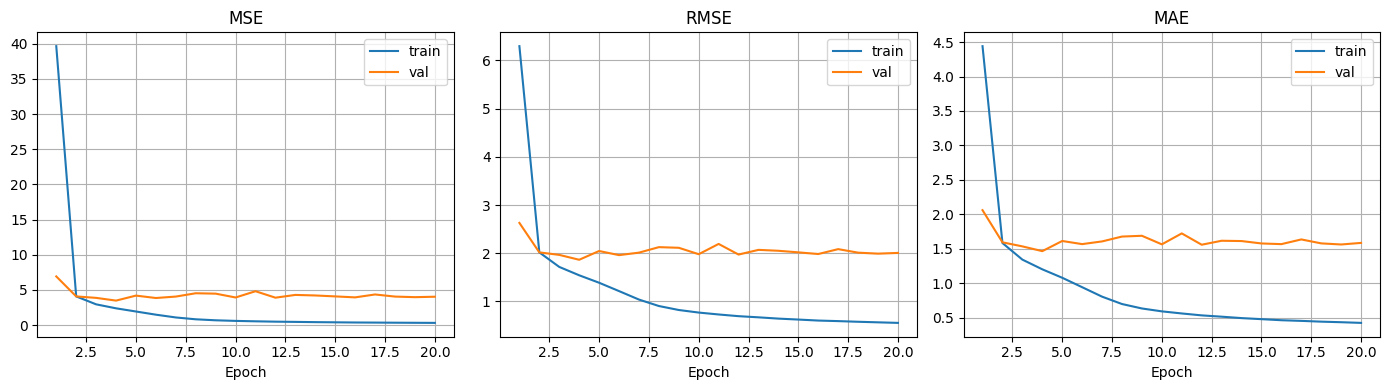

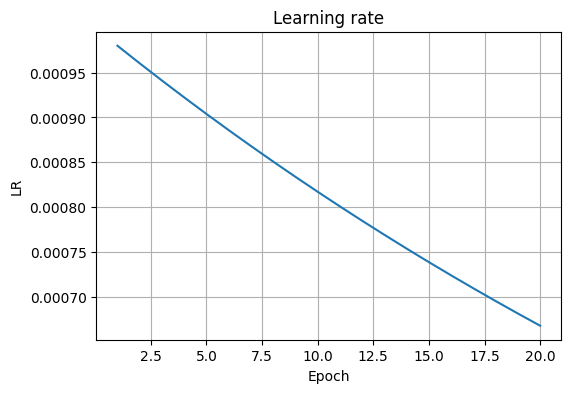

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from copy import deepcopy
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Loss / optimizer / scheduler
# -----------------------------
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.98)

save_path = Path("best_lstm_tn_tx.pt")

# -----------------------------
# Helpers
# -----------------------------
def run_epoch_metrics(model, loader, criterion, optimizer=None, device="cpu"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_abs = 0.0
    n_samples = 0

    for batch in loader:
        X_num = batch["X_num"].to(device)
        station_id = batch["station_id"].to(device)
        dept_id = batch["dept_id"].to(device)
        y = batch["y"].to(device)   # [B, 12, 2]

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            y_hat = model(X_num, station_id, dept_id)  # [B, 12, 2]
            loss = criterion(y_hat, y)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        bs = X_num.size(0)
        err = y_hat - y

        total_loss += loss.item() * bs
        total_abs += torch.abs(err).mean(dim=(1, 2)).sum().item()  # mean over 12 months and 2 targets
        n_samples += bs

    mse = total_loss / n_samples
    rmse = np.sqrt(mse)
    mae = total_abs / n_samples
    return mse, rmse, mae

# -----------------------------
# Training
# -----------------------------
num_epochs = 20
best_val_loss = float("inf")
best_state = None

history = {
    "train_mse": [],
    "train_rmse": [],
    "train_mae": [],
    "val_mse": [],
    "val_rmse": [],
    "val_mae": [],
    "lr": [],
}

for epoch in range(1, num_epochs + 1):
    train_mse, train_rmse, train_mae = run_epoch_metrics(
        model, train_loader, criterion, optimizer=optimizer, device=device
    )
    val_mse, val_rmse, val_mae = run_epoch_metrics(
        model, val_loader, criterion, optimizer=None, device=device
    )

    scheduler.step()
    lr = optimizer.param_groups[0]["lr"]

    history["train_mse"].append(train_mse)
    history["train_rmse"].append(train_rmse)
    history["train_mae"].append(train_mae)
    history["val_mse"].append(val_mse)
    history["val_rmse"].append(val_rmse)
    history["val_mae"].append(val_mae)
    history["lr"].append(lr)

    print(
        f"Epoch {epoch:02d} | "
        f"lr={lr:.2e} | "
        f"train MSE={train_mse:.4f} RMSE={train_rmse:.4f} MAE={train_mae:.4f} | "
        f"val MSE={val_mse:.4f} RMSE={val_rmse:.4f} MAE={val_mae:.4f}"
    )

    if val_mse < best_val_loss:
        best_val_loss = val_mse
        best_state = deepcopy(model.state_dict())
        torch.save(best_state, save_path)
        print(f"  -> saved new best model to {save_path}")

print("\nTraining done.")
print("Best val MSE:", best_val_loss)

if best_state is not None:
    model.load_state_dict(best_state)
    print("Best model reloaded into memory.")

# -----------------------------
# Plots
# -----------------------------
epochs = np.arange(1, len(history["train_mse"]) + 1)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs, history["train_mse"], label="train")
plt.plot(epochs, history["val_mse"], label="val")
plt.title("MSE")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(epochs, history["train_rmse"], label="train")
plt.plot(epochs, history["val_rmse"], label="val")
plt.title("RMSE")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(epochs, history["train_mae"], label="train")
plt.plot(epochs, history["val_mae"], label="val")
plt.title("MAE")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["lr"])
plt.title("Learning rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.grid(True)
plt.show()

In [6]:
import torch
import numpy as np

# -----------------------------
# Load best model weights
# -----------------------------
best_path = "best_lstm_tn_tx.pt"
model.load_state_dict(torch.load(best_path, map_location=device))
model.to(device)
model.eval()

print("Loaded best model from:", best_path)

# -----------------------------
# Test evaluation
# -----------------------------
@torch.no_grad()
def evaluate_full(model, loader, device="cpu"):
    model.eval()

    total_mse = 0.0
    total_mae = 0.0
    total_mse_tn = 0.0
    total_mae_tn = 0.0
    total_mse_tx = 0.0
    total_mae_tx = 0.0
    n_samples = 0

    for batch in loader:
        X_num = batch["X_num"].to(device)
        station_id = batch["station_id"].to(device)
        dept_id = batch["dept_id"].to(device)
        y = batch["y"].to(device)          # [B, 12, 2]

        y_hat = model(X_num, station_id, dept_id)

        err = y_hat - y

        # overall across all months and both targets
        mse_per_sample = torch.mean(err ** 2, dim=(1, 2))
        mae_per_sample = torch.mean(torch.abs(err), dim=(1, 2))

        # per target: 0=TN, 1=TX
        mse_tn_per_sample = torch.mean((err[:, :, 0]) ** 2, dim=1)
        mae_tn_per_sample = torch.mean(torch.abs(err[:, :, 0]), dim=1)

        mse_tx_per_sample = torch.mean((err[:, :, 1]) ** 2, dim=1)
        mae_tx_per_sample = torch.mean(torch.abs(err[:, :, 1]), dim=1)

        bs = X_num.size(0)
        total_mse += mse_per_sample.sum().item()
        total_mae += mae_per_sample.sum().item()
        total_mse_tn += mse_tn_per_sample.sum().item()
        total_mae_tn += mae_tn_per_sample.sum().item()
        total_mse_tx += mse_tx_per_sample.sum().item()
        total_mae_tx += mae_tx_per_sample.sum().item()
        n_samples += bs

    mse = total_mse / n_samples
    rmse = np.sqrt(mse)
    mae = total_mae / n_samples

    mse_tn = total_mse_tn / n_samples
    rmse_tn = np.sqrt(mse_tn)
    mae_tn = total_mae_tn / n_samples

    mse_tx = total_mse_tx / n_samples
    rmse_tx = np.sqrt(mse_tx)
    mae_tx = total_mae_tx / n_samples

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "mse_tn": mse_tn,
        "rmse_tn": rmse_tn,
        "mae_tn": mae_tn,
        "mse_tx": mse_tx,
        "rmse_tx": rmse_tx,
        "mae_tx": mae_tx,
    }

results = evaluate_full(model, test_loader, device=device)

print("\n=== TEST METRICS (raw °C units) ===")
print(f"Overall  MSE  = {results['mse']:.6f}")
print(f"Overall  RMSE = {results['rmse']:.4f} °C")
print(f"Overall  MAE  = {results['mae']:.4f} °C")

print("\nTN (monthly minimum temperature):")
print(f"  MSE  = {results['mse_tn']:.6f}")
print(f"  RMSE = {results['rmse_tn']:.4f} °C")
print(f"  MAE  = {results['mae_tn']:.4f} °C")

print("\nTX (monthly maximum temperature):")
print(f"  MSE  = {results['mse_tx']:.6f}")
print(f"  RMSE = {results['rmse_tx']:.4f} °C")
print(f"  MAE  = {results['mae_tx']:.4f} °C")

Loaded best model from: best_lstm_tn_tx.pt

=== TEST METRICS (raw °C units) ===
Overall  MSE  = 2.041624
Overall  RMSE = 1.4289 °C
Overall  MAE  = 1.1152 °C

TN (monthly minimum temperature):
  MSE  = 1.522480
  RMSE = 1.2339 °C
  MAE  = 0.9558 °C

TX (monthly maximum temperature):
  MSE  = 2.560768
  RMSE = 1.6002 °C
  MAE  = 1.2746 °C


In [17]:
# Cell — Load app.pt, predict 2026, and save CSV
# Assumes EncoderDecoderLSTM class is already defined in a previous cell.

import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# -----------------------------
# Paths
# -----------------------------
app_path = Path("/content/drive/MyDrive/Weather/app.pt")
best_path = Path("best_lstm_tn_tx.pt")
csv_path = Path("/content/drive/MyDrive/Weather/predictions_2026.csv")

# -----------------------------
# Load app pack
# -----------------------------
app = torch.load(app_path, map_location="cpu")

# -----------------------------
# Dataset / loader
# -----------------------------
class AppDataset(Dataset):
    def __init__(self, pack):
        self.X_num = pack["X_num"].float()
        self.station_id = pack["station_id"].long()
        self.dept_id = pack["dept_id"].long()
        self.meta = pack["meta"]

    def __len__(self):
        return self.X_num.shape[0]

    def __getitem__(self, idx):
        return {
            "X_num": self.X_num[idx],
            "station_id": self.station_id[idx],
            "dept_id": self.dept_id[idx],
        }

app_ds = AppDataset(app)
app_loader = DataLoader(app_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# -----------------------------
# Rebuild model with same architecture
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_num_features = app["X_num"].shape[-1]
n_stations = len(app["station_to_id"])
n_departments = len(app["dept_to_id"])

model = EncoderDecoderLSTM(
    n_num_features=n_num_features,
    n_stations=n_stations,
    n_departments=n_departments,
    station_emb_dim=64,
    dept_emb_dim=16,
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    output_len=12,
    output_dim=2,
).to(device)

model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

print("Loaded model from:", best_path)
print("App samples:", len(app_ds))

# -----------------------------
# Predict
# -----------------------------
all_preds = []

with torch.no_grad():
    for batch in app_loader:
        X_num = batch["X_num"].to(device)
        station_id = batch["station_id"].to(device)
        dept_id = batch["dept_id"].to(device)

        y_hat = model(X_num, station_id, dept_id)  # [B, 12, 2]
        all_preds.append(y_hat.cpu())

pred = torch.cat(all_preds, dim=0).numpy()  # [N, 12, 2]
print("Prediction tensor shape:", pred.shape)

# -----------------------------
# Build CSV
# -----------------------------
rows = []
for i, m in enumerate(app["meta"]):
    row = {
        "NUM_POSTE": m["NUM_POSTE"],
        "DEP": m["DEP"],
    }
    for j in range(12):
        row[f"MIN_{j+1}"] = float(pred[i, j, 0])  # TN
        row[f"MAX_{j+1}"] = float(pred[i, j, 1])  # TX
    rows.append(row)

df_out = pd.DataFrame(rows)

# Optional formatting
for c in df_out.columns:
    if c.startswith("MIN_") or c.startswith("MAX_"):
        df_out[c] = df_out[c].round(2)

df_out.to_csv(csv_path, index=False)
print("Saved CSV to:", csv_path)

display(df_out.head())

Loaded model from: best_lstm_tn_tx.pt
App samples: 1746
Prediction tensor shape: (1746, 12, 2)
Saved CSV to: /content/drive/MyDrive/Weather/predictions_2026.csv


,NUM_POSTE,DEP,MIN_1,MAX_1,MIN_2,MAX_2,MIN_3,MAX_3,MIN_4,MAX_4,...,MIN_8,MAX_8,MIN_9,MAX_9,MIN_10,MAX_10,MIN_11,MAX_11,MIN_12,MAX_12
0,10002001,10,2.02,8.30,2.68,11.44,3.87,14.97,5.68,17.97,...,13.51,26.89,10.24,21.90,7.24,15.91,4.65,11.88,2.94,10.08
1,10021001,10,1.90,8.55,2.57,11.73,3.65,15.07,5.42,18.27,...,12.64,26.41,9.45,21.55,6.72,16.09,4.28,12.16,2.55,10.22
2,10030001,10,1.76,8.06,2.33,11.16,3.38,14.59,5.22,17.87,...,13.05,26.72,9.77,21.69,6.83,15.79,4.27,11.78,2.52,9.90
3,10042001,10,1.49,8.32,2.11,11.77,3.06,15.21,4.77,18.14,...,12.86,26.93,9.70,22.31,6.67,16.61,4.02,12.44,2.24,10.41
4,10057001,10,2.43,8.30,2.84,10.87,3.82,14.12,5.66,17.30,...,13.66,26.59,10.61,22.00,7.72,16.10,5.06,11.91,3.35,10.06


In [13]:
df_out.shape

(1746, 26)

In [16]:
deps = df_out.DEP.unique()
for dep in deps:
  print(dep)

10
01
11
12
13
14
15
16
17
18
19
20
02
21
22
23
24
25
26
27
28
29
30
03
31
32
33
34
35
36
37
38
39
40
04
41
42
43
44
45
46
47
48
05
50
51
52
53
54
55
56
57
58
59
60
06
61
62
63
64
65
66
67
68
69
70
07
71
72
73
74
75
76
77
78
79
80
08
81
82
83
84
85
86
87
88
89
90
09
91
92
93
94
95


In [18]:
from pathlib import Path
import shutil

src = Path("best_lstm_tn_tx.pt")  # runtime file
dst = Path("/content/drive/MyDrive/Weather/best_lstm_tn_tx.pt")

shutil.copy(src, dst)
print("Saved to:", dst)

Saved to: /content/drive/MyDrive/Weather/best_lstm_tn_tx.pt
